# NSCLC atlas, lung adenocarcinoma: benchmark, UMAPs, robustness, scaling

Figures of the lung-adenocarcinoma part of the NSCLC atlas (410,927 cells from 12 datasets) and of the full atlas
(892,296 cells, scaling).

| Figure | Output (`figures/nsclc/`) |
|---|---|
| scIB benchmark table | `benchmark_results_table.pdf` |
| UMAP per method (cell type, dataset) | `umap_plots/lung_cancer_<method>_umap_<colour>.png` |
| Benchmark table and UMAPs with scGPT (zero-shot) | `benchmark_results_table_with_scgpt.pdf`, `umap_plots/lung_cancer_scGPT_*` |
| Robustness to the number of integrated datasets | `robustness/` |
| Runtime and memory against the number of cells | `scaling` |

Inputs: the benchmark object and table of `pipeline/benchmark/nsclc/` (config `benchmark.lung`), its
`robustness/<subset>/` tables, the run records of `pipeline/scaling/` (`<out_dir>/scaling/runs/`) and the scGPT scores
and UMAP coordinates of `pipeline/scgpt_zeroshot/` (`<out_dir>/scgpt/lung/`).

First run about 2.5 h and 60 GB on 16 cores (twelve UMAPs of 410,927 cells; the coordinates are cached afterwards).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

NB_DIR = Path.cwd() if (Path.cwd() / "figlib").is_dir() else Path.cwd() / "notebooks"
sys.path.insert(0, str(NB_DIR))                 # figlib; it adds pipeline/ and the prime package of this checkout

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from figlib import config, names
from figlib.display import preview, rel, show_png

CFG = config.load()                             # pipeline/config.yaml (+ config.local.yaml)
BENCH = CFG["benchmark"]                        # saved outputs of pipeline/benchmark/
N_JOBS = CFG["n_jobs"]
sc.settings.n_jobs = N_JOBS

## scIB benchmark table

wrote figures/nsclc/benchmark_results_table.pdf


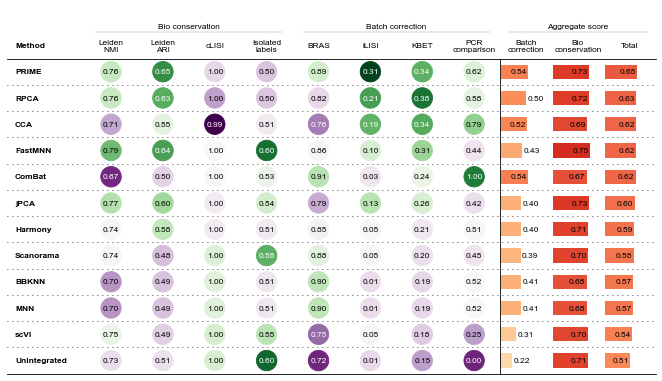

In [2]:
# scIB results table of pipeline/benchmark/nsclc/02_run_benchmark.py (scIB metrics + isolated-label score),
# drawn with the table function of that script (figlib/scib_table.py).
from figlib.scib_table import ISOLATED_LABELS_COL, plot_scib_results_table_repro

mpl.rcdefaults()
results_df = names.rename_methods(pd.read_csv(BENCH["lung"]["results_csv"], index_col=0))
col = results_df.pop(ISOLATED_LABELS_COL)            # isolated labels as the fourth column
results_df.insert(3, ISOLATED_LABELS_COL, col)
out = config.figure_dir("nsclc") / "benchmark_results_table.pdf"
with mpl.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "Arial", "figure.dpi": 300}):
    fig, ax, table = plot_scib_results_table_repro(results_df, cell_cmap=mpl.cm.PRGn, score_cmap=mpl.cm.OrRd,
                                                   sort_col="Total", figsize=(14, 8), show=False, save_path=None)
    fig.savefig(out, format="pdf", bbox_inches="tight", pad_inches=0.02)
print("wrote", rel(out))
preview(fig)

## UMAP of every method

In [3]:
# The integrated lung-adenocarcinoma data (410,927 cells, 12 datasets) with all 12 embeddings; the expression matrix
# stays on disk (backed mode), only obs, obsm and the colour palettes are read.
import anndata as ad

H5AD = BENCH["lung"]["embeddings_h5ad"]
full = ad.read_h5ad(H5AD, backed="r")
METHODS = ["PRIME", "BBKNN", "scVI", "Unintegrated", "CCA", "FastMNN", "jPCA", "RPCA", "MNN",
           "Harmony", "Scanorama", "ComBat"]
adata = sc.AnnData(obs=full.obs[["batch", "cell_type"]].copy(),
                   obsm={names.canonical(m): np.asarray(full.obsm[m]) for m in full.obsm.keys()
                         if names.canonical(m) in METHODS},
                   uns={k: v for k, v in full.uns.items() if k.endswith("_colors")})
full.file.close()
adata

AnnData object with n_obs × n_vars = 410927 × 0
    obs: 'batch', 'cell_type'
    uns: 'ann_fine_colors', 'cell_type_major_colors', 'cell_type_ontology_term_id_colors', 'cell_type_predicted_colors', 'dataset_colors', 'leiden_colors', 'origin_colors', 'platform_colors'
    obsm: 'BBKNN', 'CCA', 'ComBat', 'PRIME', 'FastMNN', 'Harmony', 'MNN', 'RPCA', 'Scanorama', 'Unintegrated', 'jPCA', 'scVI'

wrote PRIME


wrote BBKNN


wrote scVI


wrote Unintegrated


wrote CCA


...

wrote RPCA


wrote MNN


wrote Harmony


wrote Scanorama


wrote ComBat
lung_cancer_PRIME_umap_cell_type.png


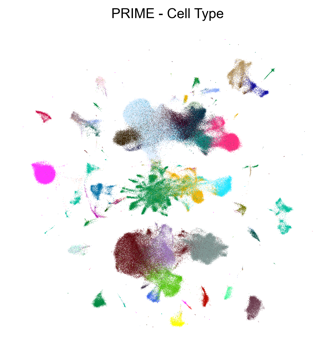

lung_cancer_PRIME_umap_batch.png


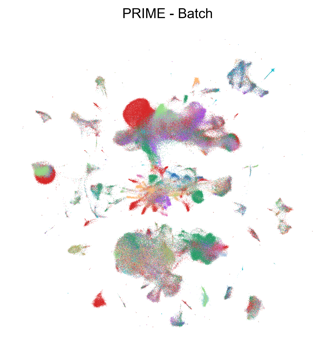

In [4]:
# UMAP per method (as pipeline/benchmark/nsclc/02_run_benchmark.py): scanpy default neighbours / UMAP on each embedding,
# one PNG coloured by cell type and one by dataset. UMAP coordinates are cached (about 10 min per method on 16 cores).
LABEL_KEY, BATCH_KEY, dataset_name = "cell_type", "batch", "lung_cancer"
OUT_DIR = config.figure_dir("nsclc", "umap_plots")
CACHE = config.cache_dir("nsclc")
mpl.rcdefaults()
for method in METHODS:
    if method not in adata.obsm:
        print(f"Warning: {method} embedding not found in adata.obsm. Skipping UMAP for this method.")
        continue
    f = CACHE / f"{method}_umap.npy"
    with mpl.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "Arial", "figure.dpi": 300}):
        if not f.exists():
            sc.pp.neighbors(adata, use_rep=method)
            sc.tl.umap(adata)
            np.save(f, adata.obsm["X_umap"])
        adata.obsm["X_umap"] = np.load(f)
        fig, axes = plt.subplots(1, 1, figsize=(5, 5))
        sc.pl.umap(adata, color=[LABEL_KEY], ax=axes, show=False, legend_loc=None, frameon=False,
                   title=f"{method} - Cell Type")
        fig.savefig(OUT_DIR / f"{dataset_name}_{method}_umap_cell_type.png", format="png", bbox_inches="tight")
        plt.close(fig)
        fig, axes = plt.subplots(1, 1, figsize=(5, 5))
        sc.pl.umap(adata, color=[BATCH_KEY], ax=axes, frameon=False, show=False, legend_loc=None,
                   title=f"{method} - Batch")
        fig.savefig(OUT_DIR / f"{dataset_name}_{method}_umap_batch.png", format="png", bbox_inches="tight")
        plt.close(fig)
    print("wrote", method)
show_png(OUT_DIR / "lung_cancer_PRIME_umap_cell_type.png", OUT_DIR / "lung_cancer_PRIME_umap_batch.png", max_px=350)

## scGPT (zero-shot)

scGPT (whole-human checkpoint) applied zero-shot to the same 2,000 HVGs and scored with the protocol of the table above
(`pipeline/scgpt_zeroshot/`).

wrote figures/nsclc/benchmark_results_table_with_scgpt.pdf


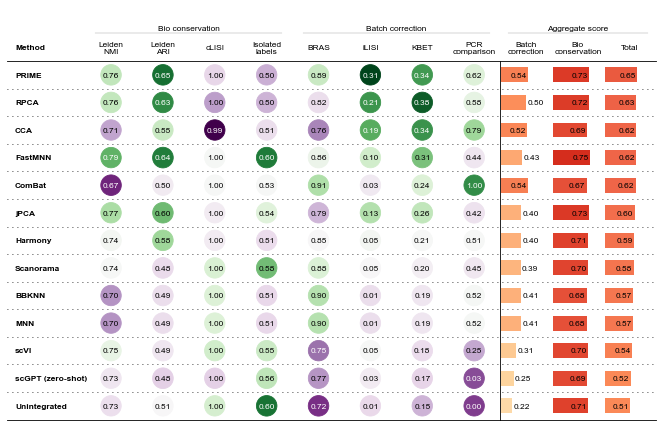

In [5]:
# The benchmark table with scGPT added. The rows of the other methods are the saved ones, unchanged; the scGPT row was
# scored by pipeline/scgpt_zeroshot/score_embeddings.py under the same protocol (scib-metrics, Leiden NMI / ARI, cLISI,
# BRAS, iLISI, kBET, PCR comparison, isolated-label silhouette; Total = 0.6 Bio + 0.4 Batch) and merged by
# collect_tables.py. scGPT (zero-shot): the pre-trained whole-human model applied as it is (no training, no batch
# information) to the same 2,000 HVGs as every other method.
SCGPT_DIR = CFG["out_dir"] / "scgpt" / "lung"
mpl.rcdefaults()
results_df = names.rename_methods(pd.read_csv(SCGPT_DIR / "scores" / "benchmark_results_with_scgpt.csv", index_col=0))
col = results_df.pop(ISOLATED_LABELS_COL)
results_df.insert(3, ISOLATED_LABELS_COL, col)
out = config.figure_dir("nsclc") / "benchmark_results_table_with_scgpt.pdf"
with mpl.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "Arial", "figure.dpi": 300}):
    fig, ax, table = plot_scib_results_table_repro(results_df, cell_cmap=mpl.cm.PRGn, score_cmap=mpl.cm.OrRd,
                                                   sort_col="Total", figsize=(14, 9), show=False, save_path=None)
    fig.savefig(out, format="pdf", bbox_inches="tight", pad_inches=0.02)
print("wrote", rel(out))
preview(fig)

wrote scGPT_zeroshot
lung_cancer_scGPT_zeroshot_umap_batch.png


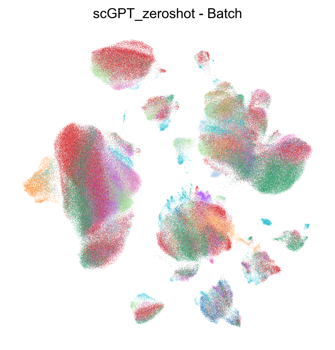

lung_cancer_scGPT_zeroshot_umap_cell_type.png


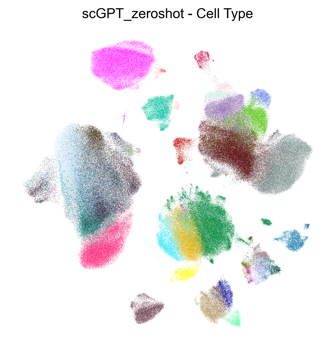

In [6]:
# UMAPs of the scGPT embeddings (pipeline/scgpt_zeroshot/embedding_umap.py, scanpy defaults as for the other methods),
# drawn like the panels above; coordinates are read from the saved results.
SCGPT_RUNS = [("scGPT_zeroshot_hvg", "scGPT_zeroshot")]
for name, method in SCGPT_RUNS:
    f = SCGPT_DIR / "umap" / f"{name}.npy"
    if not f.exists():
        print("missing", f.name)
        continue
    adata.obsm["X_umap"] = np.load(f)
    with mpl.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "Arial", "figure.dpi": 300}):
        for key, label, tag in ((LABEL_KEY, "Cell Type", "cell_type"), (BATCH_KEY, "Batch", "batch")):
            fig, axes = plt.subplots(1, 1, figsize=(5, 5))
            sc.pl.umap(adata, color=[key], ax=axes, show=False, legend_loc=None, frameon=False, title=f"{method} - {label}")
            fig.savefig(OUT_DIR / f"{dataset_name}_{method}_umap_{tag}.png", format="png", bbox_inches="tight")
            plt.close(fig)
    print("wrote", method)
show_png(OUT_DIR / "lung_cancer_scGPT_zeroshot_umap_batch.png", OUT_DIR / "lung_cancer_scGPT_zeroshot_umap_cell_type.png", max_px=350)

## Robustness to the number of integrated datasets

[info] no results for n10_rep2 (not finished); skipped
[info] no results for n10_rep3 (not finished); skipped
[info] no results for n10_rep4 (not finished); skipped
[info] no results for n10_rep5 (not finished); skipped
n_datasets
4     5
6     5
8     5
10    1


Wrote robustness_curves.pdf


Wrote robustness_curves.png
n04_batch_bio_total.png


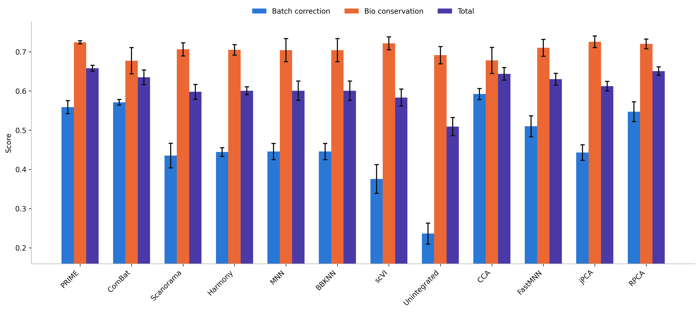

BRAS.png


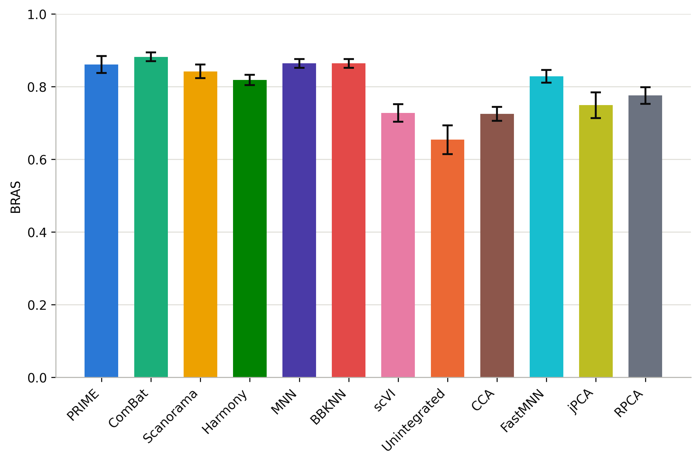

In [7]:
# Robustness to the number of integrated datasets (random subsets of 4, 6, 8, 10 of the 12 datasets, 5 replicates;
# pipeline/benchmark/nsclc/03-06). Per-subset scIB tables -> one bar plot per metric and n, the grouped aggregate-score
# plot, and the score-vs-n curves. Subsets whose benchmark did not finish are listed and left out.
from figlib import robustness as RB

mpl.rcdefaults()
ROBUST = Path(BENCH["lung"]["dir"]) / "robustness"
long = RB.load_subset_results(ROBUST)
print(long.groupby("n_datasets")["replicate"].nunique().rename("replicates with results").to_string())
BAR_DIR = config.figure_dir("nsclc", "robustness", "benchmark_barplots")
metrics = [m for m in long.metric.unique()]
for n in sorted(long.n_datasets.unique()):
    d = config.figure_dir("nsclc", "robustness", "benchmark_barplots", f"n{n:02d}")
    for m in metrics:
        RB.plot_metric_bars(long, n, m, d / f"{m.replace(' ', '_')}.png")
    RB.plot_score_bars(long, n, config.figure_dir("nsclc", "robustness", "benchmark_barplots", "combined")
                       / f"n{n:02d}_batch_bio_total.png")
full_ref = names.rename_methods(pd.read_csv(BENCH["lung"]["results_csv"], index_col=0))
full_ref = full_ref[full_ref.index.isin(RB.METHOD_ORDER)].apply(pd.to_numeric, errors="coerce")
full_long = full_ref.reset_index(names="Method").melt(id_vars="Method", var_name="metric", value_name="score")
long_curves = pd.concat([long, full_long.assign(n_datasets=12, replicate=0)], ignore_index=True)
RB.plot_robustness_curves(long_curves[long_curves.metric.isin(["Total", "Bio conservation", "Batch correction"])],
                          config.figure_dir("nsclc", "robustness"))
show_png(BAR_DIR / "combined" / "n04_batch_bio_total.png", BAR_DIR / "n04" / "BRAS.png", max_px=700)

## Scaling

Drawn from the run records under `out_dir` of the pipeline configuration.

In [8]:
# Style and helpers of the analysis figures (figlib/style.py): palette, save, panel, load, sweep, ...
# OUT = out_dir of the pipeline configuration (result tables); figures are written to figures/nsclc/.
import figlib.style as S
from figlib.style import *          # CFG, OUT, C (pipeline/common.py), palette, save, panel, load, sweep, ...
S.set_figure_dir(config.figure_dir("nsclc"))


def draw(fn, name):
    S.apply_style()
    fn()
    png = S.FIG / f"{name}.png"
    if png.exists():
        show_png(png, max_px=1100)
    else:
        print(f"{name}: input tables not found under out_dir; figure skipped")

### Runtime and memory

Integration time and peak memory against the number of cells (nested subsets of the full NSCLC atlas).

In [9]:
SCALING_ORDER = [("prime_chunk200", "PRIME", SLOT[0], "-"),        # gene-chunked correction (chunk_size = 200)
            ("harmony", "Harmony", SLOT[1], "-"), ("scanorama", "Scanorama", SLOT[2], "-"),
            ("scvi", "scVI", SLOT[3], "-"), ("fastmnn", "FastMNN", SLOT[4], "-"), ("rpca", "Seurat RPCA", SLOT[5], "-")]


def scaling_runs():
    rows = []
    for f in glob.glob(str(OUT / "scaling/runs" / "*.json")):
        if f.endswith(".stages.json"):
            continue
        rows.append(json.loads(Path(f).read_text()))
    if not rows:
        return None
    d = pd.DataFrame(rows)
    d["m"] = np.where((d.method == "prime") & (d.prime_chunk == 200), "prime_chunk200", d.method)
    d["rep"] = d.get("rep", 0)
    d["rep"] = d["rep"].fillna(0)
    return d


def fig_scaling():
    """Integration time (a) and peak memory (b) against the number of cells."""
    d = scaling_runs()
    if d is None:
        return
    ok = d[(d.status == "ok") & d.subset.str.startswith("N")].assign(n=lambda x: x.subset.str[1:].astype(int))
    fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.9))
    for ax, y, yl, letter in ((axes[0], "core_s", "Integration time (s)", "a"),
                              (axes[1], "peak_rss_gb", "Peak memory, whole process tree (GB)", "b")):
        for key, name, col, ls in SCALING_ORDER:
            g = ok[ok.m == key].groupby("n")[y].agg(["mean", "std"])
            if not g.empty:
                ax.errorbar(g.index, g["mean"], yerr=g["std"].fillna(0), color=col, ls=ls, marker="o", ms=3, lw=1.4,
                            capsize=0, label=name)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Cells")
        ax.set_ylabel(yl)
        panel(ax, letter)
    fm = d[(d.m == "fastmnn") & (d.subset == "N892296")]
    if len(fm) and (fm.status != "ok").all():
        axes[1].annotate("FastMNN: out of memory\n(> 160 GB) at 892k cells", (892296, 160), fontsize=5.5,
                         xytext=(-95, -2), textcoords="offset points", color=SLOT[4])
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=6)
    fig.tight_layout()
    save(fig, "scaling")

wrote figures/nsclc/scaling


scaling.png


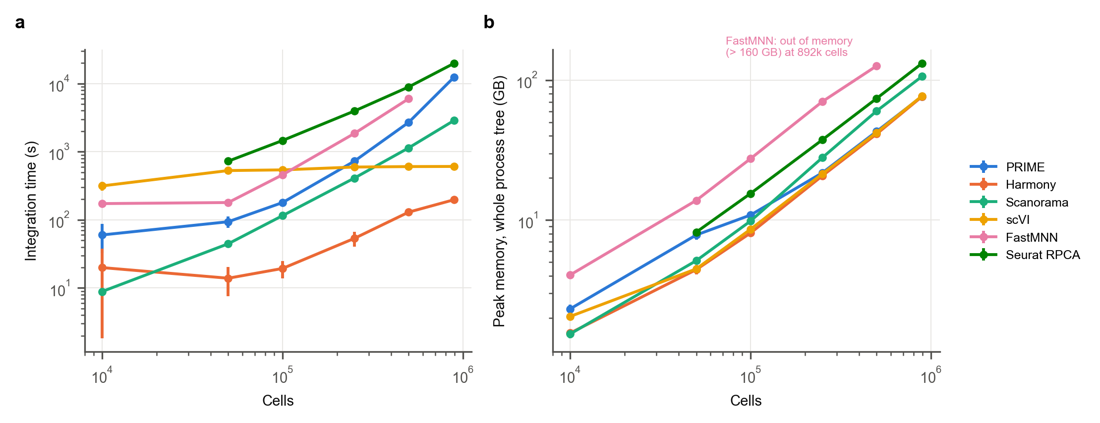

In [10]:
draw(fig_scaling, "scaling")